In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [2]:
df = pd.read_csv('amazon_prime_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,The Grand Seduction,Don McKellar,"Brendan Gleeson, Taylor Kitsch, Gordon Pinsent",Canada,"March 30, 2021",2014,NaN,113 min,"Comedy, Drama",A small fishing village must procure a local d...
1,s2,Movie,Take Care Good Night,Girish Joshi,"Mahesh Manjrekar, Abhay Mahajan, Sachin Khedekar",India,"March 30, 2021",2018,13+,110 min,"Drama, International",A Metro Family decides to fight a Cyber Crimin...
2,s3,Movie,Secrets of Deception,Josh Webber,"Tom Sizemore, Lorenzo Lamas, Robert LaSardo, R...",United States,"March 30, 2021",2017,NaN,74 min,"Action, Drama, Suspense",After a man discovers his wife is cheating on ...
3,s4,Movie,Pink: Staying True,Sonia Anderson,"Interviews with: Pink, Adele, Beyoncé, Britney...",United States,"March 30, 2021",2014,NaN,69 min,Documentary,"Pink breaks the mold once again, bringing her ..."
4,s5,Movie,Monster Maker,Giles Foster,"Harry Dean Stanton, Kieran O'Brien, George Cos...",United Kingdom,"March 30, 2021",1989,NaN,45 min,"Drama, Fantasy",Teenage Matt Banting wants to work with a famo...


In [3]:
df.rename(columns = {'listed_in' : 'genre'}, inplace = True)
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genre,description
0,s1,Movie,The Grand Seduction,Don McKellar,"Brendan Gleeson, Taylor Kitsch, Gordon Pinsent",Canada,"March 30, 2021",2014,NaN,113 min,"Comedy, Drama",A small fishing village must procure a local d...
1,s2,Movie,Take Care Good Night,Girish Joshi,"Mahesh Manjrekar, Abhay Mahajan, Sachin Khedekar",India,"March 30, 2021",2018,13+,110 min,"Drama, International",A Metro Family decides to fight a Cyber Crimin...
2,s3,Movie,Secrets of Deception,Josh Webber,"Tom Sizemore, Lorenzo Lamas, Robert LaSardo, R...",United States,"March 30, 2021",2017,NaN,74 min,"Action, Drama, Suspense",After a man discovers his wife is cheating on ...
3,s4,Movie,Pink: Staying True,Sonia Anderson,"Interviews with: Pink, Adele, Beyoncé, Britney...",United States,"March 30, 2021",2014,NaN,69 min,Documentary,"Pink breaks the mold once again, bringing her ..."
4,s5,Movie,Monster Maker,Giles Foster,"Harry Dean Stanton, Kieran O'Brien, George Cos...",United Kingdom,"March 30, 2021",1989,NaN,45 min,"Drama, Fantasy",Teenage Matt Banting wants to work with a famo...


In [4]:
df.describe()

,release_year
count,9668.000000
mean,2008.341849
std,18.922482
min,1920.000000
25%,2007.000000
50%,2016.000000
75%,2019.000000
max,2021.000000


In [5]:
print ("Dataset shape:")
df.shape

Dataset shape:


(9668, 12)

In [6]:
df.info() #before pre-processing

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9668 entries, 0 to 9667
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       9668 non-null   object
 1   type          9668 non-null   object
 2   title         9668 non-null   object
 3   director      7585 non-null   object
 4   cast          8435 non-null   object
 5   country       672 non-null    object
 6   date_added    155 non-null    object
 7   release_year  9668 non-null   int64 
 8   rating        9331 non-null   object
 9   duration      9668 non-null   object
 10  genre         9668 non-null   object
 11  description   9668 non-null   object
dtypes: int64(1), object(11)
memory usage: 906.5+ KB


In [7]:
#pre-processing
#checks for missing/null values and if none then there is no removal
df.isnull().any()
#director, cast, country, date_added and rating cannot be removed as they are important columns 
#therefore will be replaced with unknown

show_id         False
type            False
title           False
director         True
cast             True
country          True
date_added       True
release_year    False
rating           True
duration        False
genre           False
description     False
dtype: bool

In [8]:
df_null=df.isna().sum()/df.shape[0]*100
df_null[df_null>0]

director      21.545304
cast          12.753413
country       93.049235
date_added    98.396773
rating         3.485726
dtype: float64

In [9]:
df.fillna({'director':'Unknown','cast':'Unknown',"country":'Unknown', "date_added": 'unknown', 'rating':'Unknown'},inplace=True) #filling missing values with unknown

In [10]:
df.isnull().sum() #checks for how many missing values are there in each column and there are none so no removal

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
genre           0
description     0
dtype: int64

In [11]:
df.shape

(9668, 12)

In [12]:
#check for duplicates - if none then no removal
df.duplicated().sum()

0

In [13]:
#check for unique values in each column
df.nunique()

show_id         9668
type               2
title           9668
director        5774
cast            7928
country           87
date_added        85
release_year     100
rating            25
duration         219
genre            518
description     9414
dtype: int64

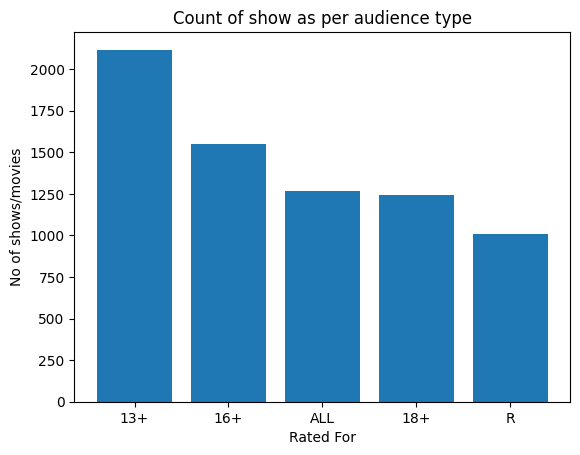

In [14]:
#data visualisation
#1. Number of movies vs TV shows
count_by_rating = df['rating'].value_counts() #count of shows/movies as per audience type
plt.bar(count_by_rating.index[:5], count_by_rating.values[:5]) #top 5 audience type
plt.xlabel("Rated For")
plt.ylabel("No of shows/movies")
plt.title("Count of show as per audience type")
plt.show()

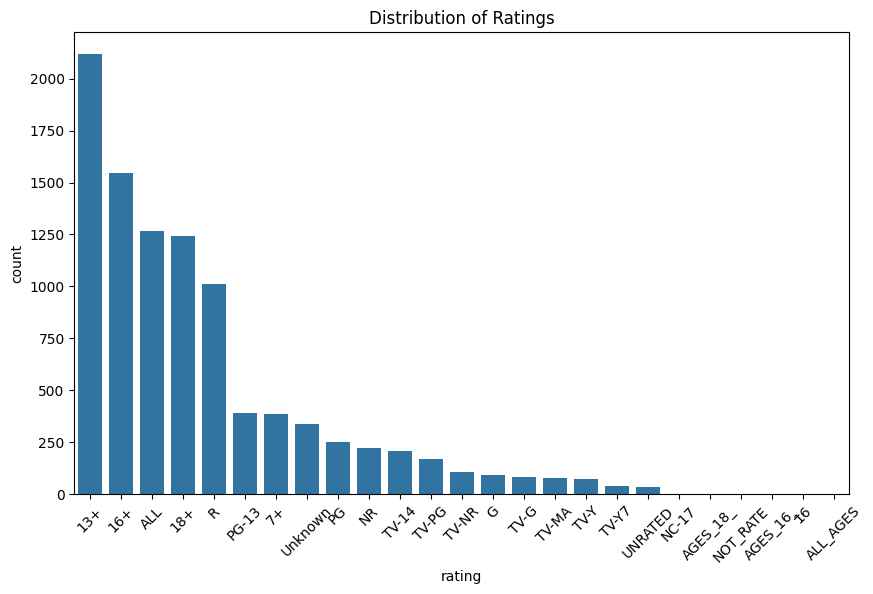

In [15]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='rating', order=df['rating'].value_counts().index)
plt.title('Distribution of Ratings')
plt.xticks(rotation=45)
plt.show()

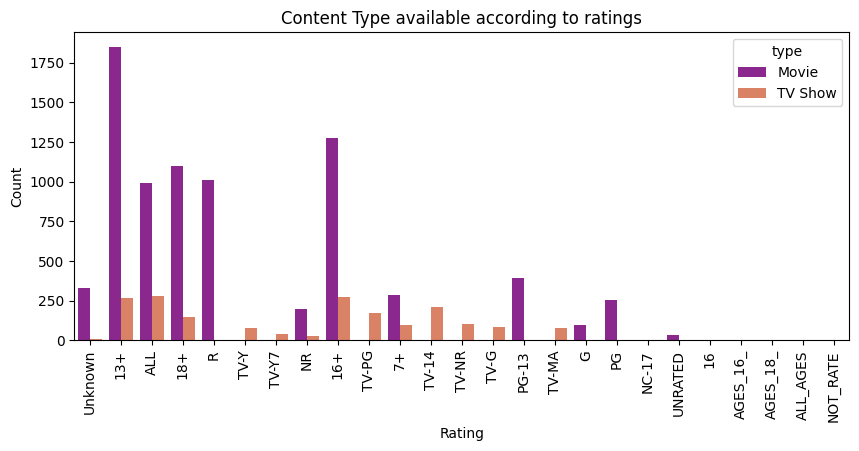

In [16]:
plt.figure(figsize=(10,4))
ax=sns.countplot(data = df,x='rating',hue='type',palette='plasma')
plt.title('Content Type available according to ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=90)
#ax.legend(loc='center left', bbox_to_anchor=(0.600,0.90),
#          ncol=3, fancybox=True, shadow=True)
plt.show()

C:\Users\purvi\AppData\Local\Temp\ipykernel_4760\3795593502.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="type", data=df, palette = "viridis")


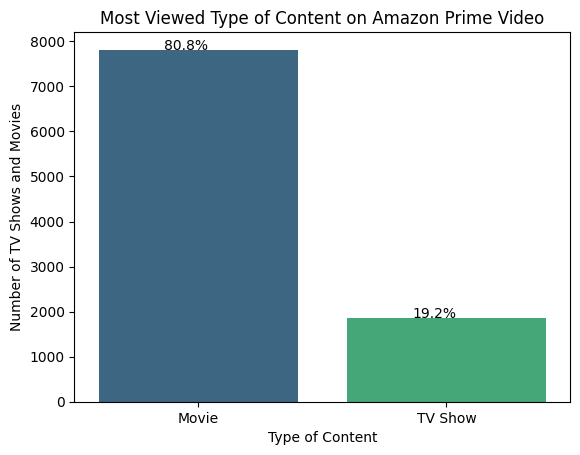

In [17]:
#2. count of shows/movies 
# count of shows/movies as per genre
ax = sns.countplot(x="type", data=df, palette = "viridis")
#adds percentage on top of the bars
total = len(df)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total)
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center')

plt.xlabel('Type of Content')
plt.ylabel('Number of TV Shows and Movies')
plt.title('Most Viewed Type of Content on Amazon Prime Video') 
plt.show()

Text(0.5, 1.0, 'Top 10 directors by number of shows directed')

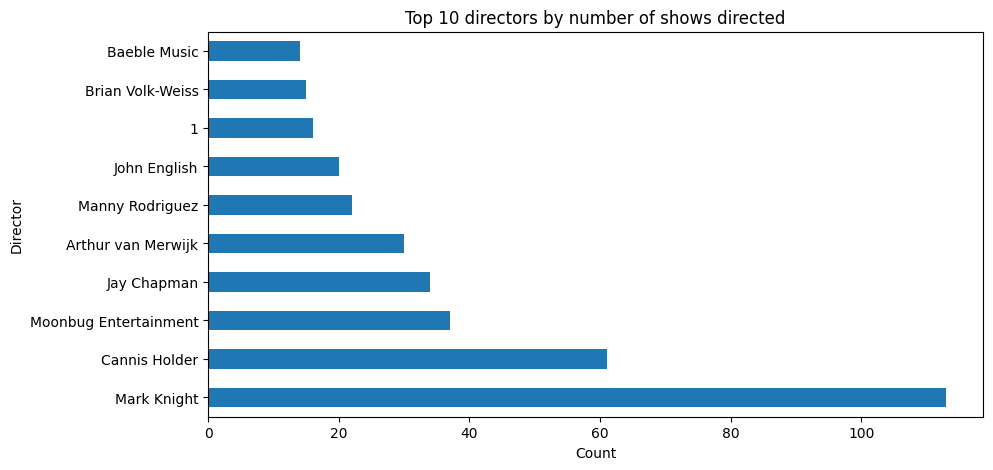

In [18]:
#3. Top 10 directors in the dataset
plt.figure(figsize=(10,5))
df[~(df['director']=='Unknown')].director.value_counts().nlargest(10).plot(kind='barh')
plt.xlabel('Count')
plt.ylabel('Director')
plt.title('Top 10 directors by number of shows directed')

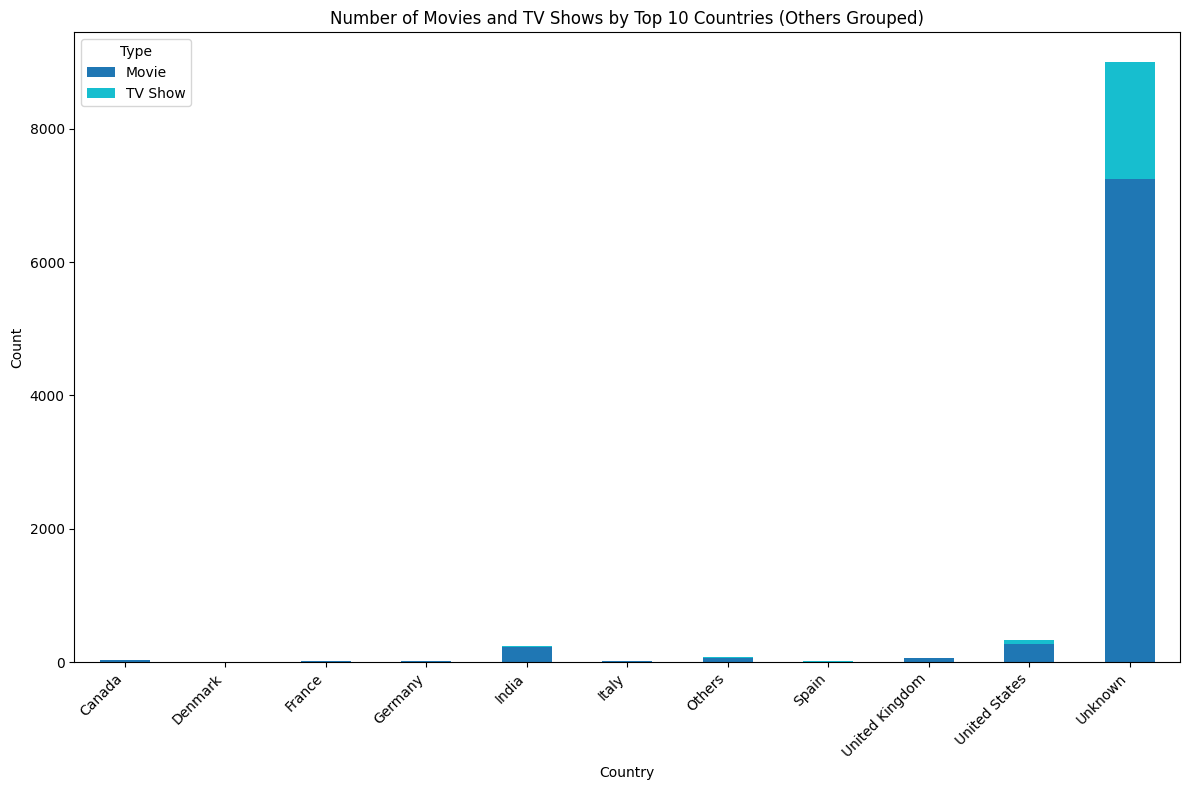

type
Movie      80.823335
TV Show    19.176665
Name: proportion, dtype: float64

In [19]:
#4. Top 10 countries with most content - US has the most content produced
top_countries = df['country'].str.split(', ').explode().value_counts().nlargest(10).index
df['country'].str.split(', ').explode() \
    .apply(lambda x: x if x in top_countries else 'Others')\
    .reset_index().merge(df.drop(columns='country'), left_on='index', right_index=True) \
    .groupby(['country', 'type']).size().reset_index(name='count') \
    .pivot(index='country', columns='type', values='count').fillna(0) \
    .plot(kind='bar', stacked=True, figsize=(12, 8), colormap='tab10')

# Customize plot
plt.title("Number of Movies and TV Shows by Top 10 Countries (Others Grouped)")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Type")
plt.tight_layout()
plt.show()

#percentage of movies and tv shows 
df['type'].value_counts(normalize=True)*100

C:\Users\purvi\AppData\Local\Temp\ipykernel_4760\4123674313.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_categories.index, y=top_10_categories.values, palette='viridis')


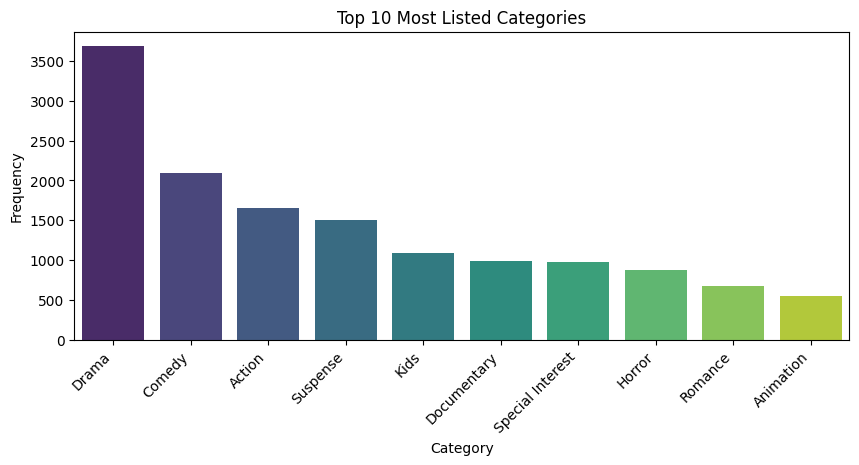

In [20]:
categories = df['genre'].str.split(',').explode().str.strip()  
top_10_categories = categories.value_counts().head(10)

plt.figure(figsize=(10, 4))
sns.barplot(x=top_10_categories.index, y=top_10_categories.values, palette='viridis')

plt.title('Top 10 Most Listed Categories')
plt.xlabel('Category')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')

plt.show()

C:\Users\purvi\AppData\Local\Temp\ipykernel_4760\2708869649.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_countries.index, y=top_10_countries.values, palette='viridis')


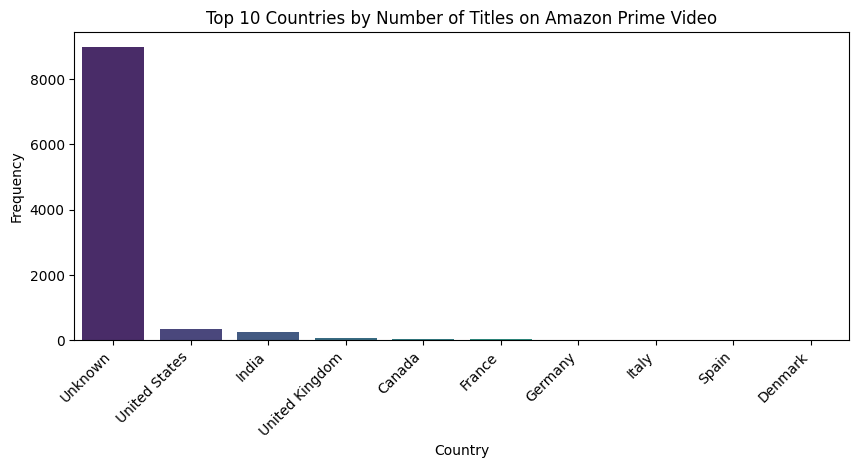

In [21]:
countries = df['country'].str.split(',').explode().str.strip()  
top_10_countries = countries.value_counts().head(10)

plt.figure(figsize=(10, 4))
sns.barplot(x=top_10_countries.index, y=top_10_countries.values, palette='viridis')

plt.title('Top 10 Countries by Number of Titles on Amazon Prime Video')
plt.xlabel('Country')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.show()

<Axes: xlabel='release_year'>

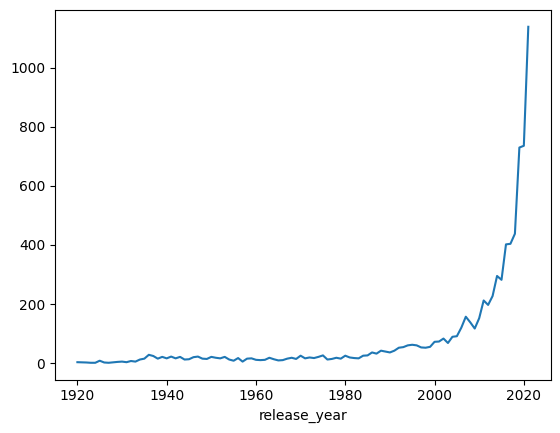

In [22]:
#from 2010 to 2020 number of movies released is grosing fast
mov = df[df['type'] == 'Movie']
mov.groupby("release_year")['type'].count().plot()

<Axes: xlabel='release_year'>

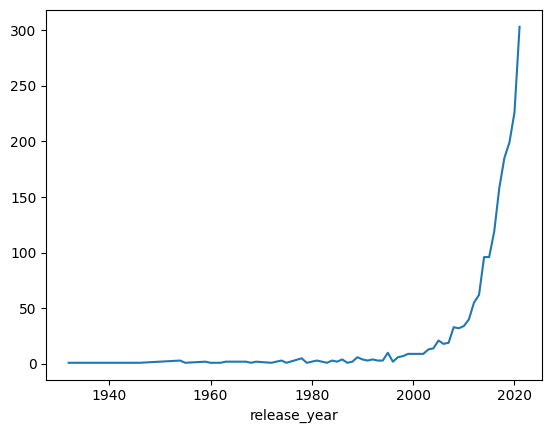

In [23]:
#from 2017 to 2020 number of tv shows released grows fast
TV = df[df['type'] == 'TV Show']
TV.groupby("release_year")['type'].count().plot()

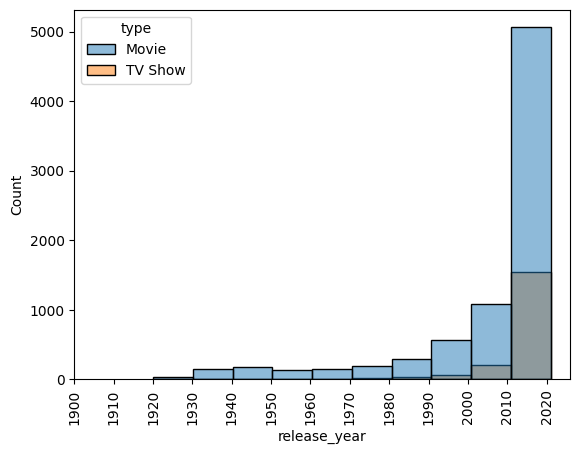

In [24]:
sns.histplot(x='release_year',data=df,bins=10,hue='type')
plt.xticks(range(1900, 2026, 10),rotation=90)
plt.show()

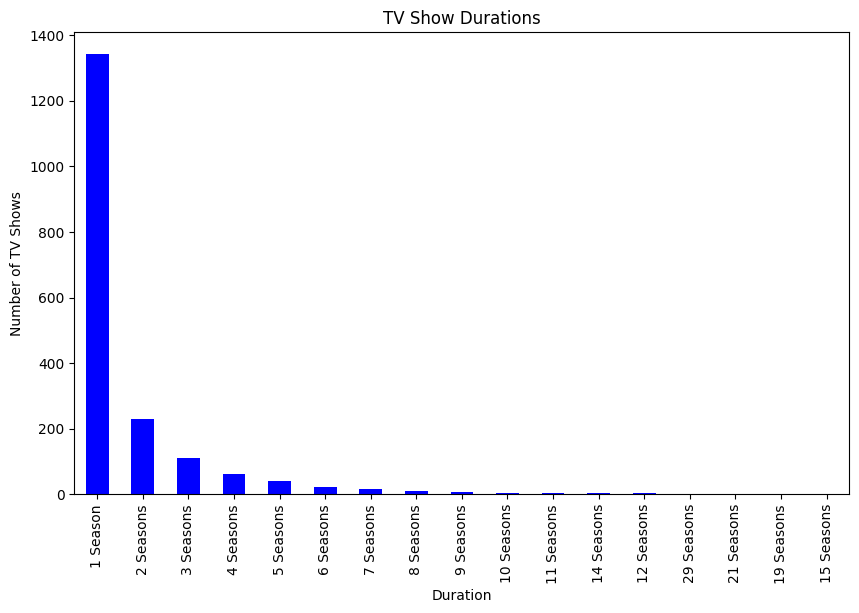

In [25]:
tv_shows = df[df['type'] == 'TV Show']

tv_shows_no_nan = tv_shows.dropna(subset=['duration'])

duration_counts = tv_shows_no_nan['duration'].value_counts()

plt.figure(figsize=(10, 6))
duration_counts.plot(kind='bar', color='blue')
plt.title('TV Show Durations')
plt.xlabel('Duration')
plt.ylabel('Number of TV Shows')
plt.xticks(rotation=90)
plt.show()

<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
C:\Users\purvi\AppData\Local\Temp\ipykernel_4760\1790818908.py:5: SyntaxWarning: invalid escape sequence '\d'
  movies['duration_minutes'] = movies['duration'].str.extract('(\d+)').astype(float)


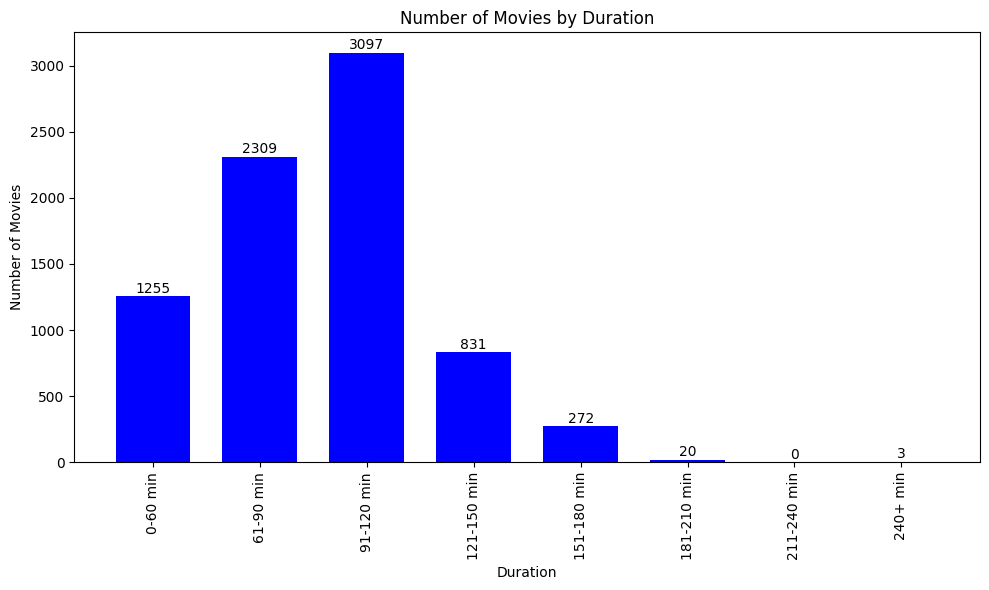

In [26]:
movies = df[df['type'] == 'Movie'].copy()

movies = movies.dropna(subset=['duration'])

movies['duration_minutes'] = movies['duration'].str.extract('(\d+)').astype(float)

bins = [0, 60, 90, 120, 150, 180, 210, 240, 300]
labels = ['0-60 min', '61-90 min', '91-120 min', '121-150 min', '151-180 min', '181-210 min', '211-240 min', '240+ min']
movies['duration_group'] = pd.cut(movies['duration_minutes'], bins=bins, labels=labels, right=False)

duration_group_counts = movies['duration_group'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
bars = plt.bar(duration_group_counts.index, duration_group_counts.values, color='blue', width=0.7)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), ha='center', va='bottom')

plt.xlabel('Duration')
plt.ylabel('Number of Movies')
plt.title('Number of Movies by Duration')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [27]:
#training and testing the data
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import LabelEncoder #convert strings into numbers
from sklearn.preprocessing import StandardScaler
scale=StandardScaler()
labelencoder = LabelEncoder()
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genre,description
0,s1,Movie,The Grand Seduction,Don McKellar,"Brendan Gleeson, Taylor Kitsch, Gordon Pinsent",Canada,"March 30, 2021",2014,Unknown,113 min,"Comedy, Drama",A small fishing village must procure a local d...
1,s2,Movie,Take Care Good Night,Girish Joshi,"Mahesh Manjrekar, Abhay Mahajan, Sachin Khedekar",India,"March 30, 2021",2018,13+,110 min,"Drama, International",A Metro Family decides to fight a Cyber Crimin...
2,s3,Movie,Secrets of Deception,Josh Webber,"Tom Sizemore, Lorenzo Lamas, Robert LaSardo, R...",United States,"March 30, 2021",2017,Unknown,74 min,"Action, Drama, Suspense",After a man discovers his wife is cheating on ...
3,s4,Movie,Pink: Staying True,Sonia Anderson,"Interviews with: Pink, Adele, Beyoncé, Britney...",United States,"March 30, 2021",2014,Unknown,69 min,Documentary,"Pink breaks the mold once again, bringing her ..."
4,s5,Movie,Monster Maker,Giles Foster,"Harry Dean Stanton, Kieran O'Brien, George Cos...",United Kingdom,"March 30, 2021",1989,Unknown,45 min,"Drama, Fantasy",Teenage Matt Banting wants to work with a famo...


In [28]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
labelencoder = LabelEncoder()

In [29]:
#encoding the unscaled data
df_unscaled = df 
df_unscaled = df_unscaled.apply(labelencoder.fit_transform) #converts strings into numbers
df_unscaled

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genre,description
0,0,0,8009,1464,984,8,47,92,24,20,267,1169
1,1111,0,7489,1898,4639,26,47,96,0,17,387,237
2,2222,0,6796,2789,7384,60,47,95,24,189,71,1723
3,3333,0,6038,5017,2932,60,47,92,24,182,321,6306
4,4444,0,5225,1888,2760,51,47,67,24,146,368,7235
...,...,...,...,...,...,...,...,...,...,...,...,...
9663,9627,0,6192,2762,4377,86,84,18,4,172,261,5941
9664,9628,1,6101,5488,1585,86,84,96,0,139,513,8097
9665,9629,0,5835,5103,6009,86,84,86,15,209,0,4827
9666,9630,1,4939,5488,2288,86,84,99,18,1,420,7782


In [30]:
df_unscaled.corr()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genre,description
show_id,1.000000,-0.182758,0.099900,-0.122311,-0.072854,0.081266,-0.028888,-0.019031,-0.129962,0.077015,-0.052307,-0.055017
type,-0.182758,1.000000,0.006375,0.543705,0.094726,0.038462,-0.191915,0.159723,0.178938,-0.459801,0.095314,0.078344
title,0.099900,0.006375,1.000000,-0.022999,0.028109,0.000894,0.013170,-0.056470,-0.014395,-0.002788,-0.002043,0.078717
director,-0.122311,0.543705,-0.022999,1.000000,0.111039,-0.002453,-0.103267,0.086899,0.097399,-0.298346,0.067600,0.061920
cast,-0.072854,0.094726,0.028109,0.111039,1.000000,0.015980,-0.005345,0.073304,0.009209,-0.068179,0.038275,0.063646
country,0.081266,0.038462,0.000894,-0.002453,0.015980,1.000000,0.043166,-0.070628,0.062082,0.078729,0.011112,0.003700
date_added,-0.028888,-0.191915,0.013170,-0.103267,-0.005345,0.043166,1.000000,-0.041783,-0.065405,0.006918,0.024683,-0.030001
release_year,-0.019031,0.159723,-0.056470,0.086899,0.073304,-0.070628,-0.041783,1.000000,0.005224,-0.116439,0.028722,0.018578
rating,-0.129962,0.178938,-0.014395,0.097399,0.009209,0.062082,-0.065405,0.005224,1.000000,-0.042273,0.000004,0.006412
duration,0.077015,-0.459801,-0.002788,-0.298346,-0.068179,0.078729,0.006918,-0.116439,-0.042273,1.000000,-0.027518,-0.054568


<Axes: >

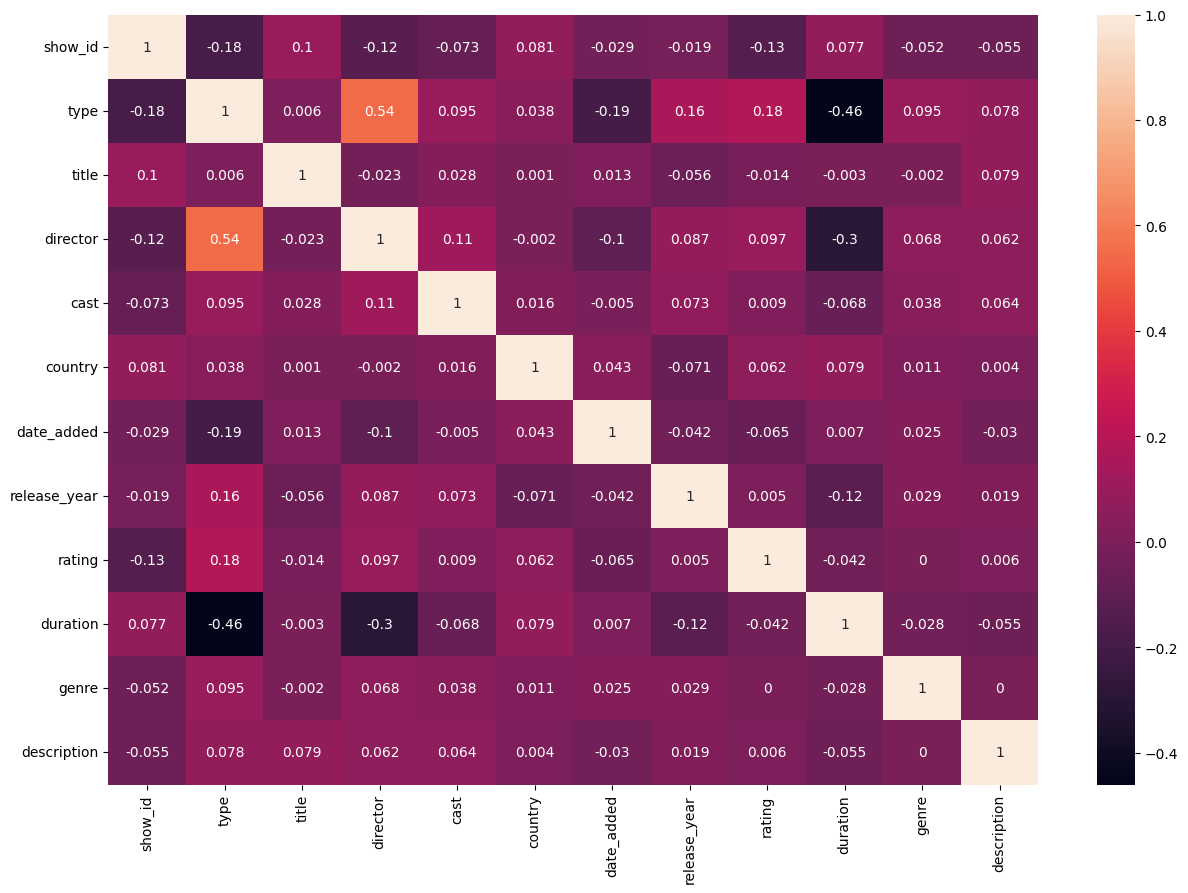

In [31]:
correlation_matrix = df_unscaled.corr().round(3)
plt.figure(figsize=(15,10))
sns.heatmap(data=correlation_matrix, annot=True)

In [32]:
#applying machine learning algorithms
from sklearn import metrics
from scipy.sparse.linalg import svds
from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import precision_score, recall_score, mean_squared_error, mean_absolute_error
import math
import random
import time
from pyspark.sql import SparkSession
from pyspark.ml.recommendation import ALS
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [33]:
#1. Collaborative Filtering - SVD
#3 user cases - same in all algorithms
#classification report - training, accuracy, precision, recall, f1-score, support, testing

In [34]:
#user ratings
df['movieId'] = df.index
# Simulate user ratings (for 50 users and random scores between 1 and 5)
ratings_df = df[['movieId']].copy()
ratings_df['userId'] = np.random.randint(1, 51, size=len(df))
ratings_df['rating'] = np.random.randint(1, 6, size=len(df))

#user-item matrix
user_item_matrix = ratings_df.pivot(index='userId', columns='movieId', values='rating').fillna(0)

#measure efficiency
start_time = time.time()

#mean-center the ratings (subtract each user's average rating)
user_ratings_mean = np.mean(user_item_matrix.values, axis=1).reshape(-1, 1)
R_demeaned = user_item_matrix.values - user_ratings_mean

# apply SVD
U, sigma, Vt = svds(R_demeaned, k=20)
sigma = np.diag(sigma)

# reconstruct predictions
all_user_predicted_ratings = np.dot(np.dot(U, sigma), Vt) + user_ratings_mean
predicted_df = pd.DataFrame(all_user_predicted_ratings, index=user_item_matrix.index, columns=user_item_matrix.columns)

#end timer and report efficiency
end_time = time.time()
print("✅ SVD model trained successfully.")
print(f"⏱ Efficiency: SVD ran in {round(end_time - start_time, 3)} seconds.")


✅ SVD model trained successfully.
⏱ Efficiency: SVD ran in 0.223 seconds.


In [35]:
#User Case 1 - Recommend to user top 5 movie titles that match based on movie searched for
np.random.seed(42)
random.seed(42)

def svd_recommend_by_title(user_id, title, df, predicted_df, top_n=5):
    start_time = time.time()

    movie = df[df['title'].str.contains(title, case=False, na=False)]
    if movie.empty:
        print("Movie title not found.")
        return []
    movie_id = movie.iloc[0]['movieId']

    predictions = [(mid, predicted_df.loc[user_id, mid]) 
                   for mid in predicted_df.columns if mid != movie_id]

    sorted_predictions = sorted(predictions, key=lambda x: x[1], reverse=True)[:top_n]
    rec_ids = [mid for mid, _ in sorted_predictions]

    end_time = time.time()
    print(f"⏱ User Case 1 executed in {round(end_time - start_time, 3)} seconds.")

    return df[df['movieId'].isin(rec_ids)][['title', 'movieId']]

# Example usage
user_id_example = 10
print("🎬 House of Cards - Title-Based Recommendations:")
print(svd_recommend_by_title(user_id_example, "House of Cards", df, predicted_df))


🎬 House of Cards - Title-Based Recommendations:
⏱ User Case 1 executed in 0.389 seconds.
                                                  title  movieId
103                              Wild Colombia Revealed      103
1234                                             QB VII     1234
1295                               Planet Of The Humans     1295
1383                                       Paper Planes     1383
1457  Nursery Rhymes Volume 10 by Little Baby Bum - ...     1457


In [36]:
#User Case 2 - Recommend to user top 5 based on searched genre in this case "Drama"
np.random.seed(42)
random.seed(42)

def svd_recommend_by_genre(user_id, genre, df, predicted_df, top_n=5):
    start_time = time.time()

    genre_df = df[df['genre'].str.contains(genre, case=False, na=False)]

    predictions = [(row['movieId'], predicted_df.loc[user_id, row['movieId']])
                   for _, row in genre_df.iterrows()
                   if row['movieId'] in predicted_df.columns]

    sorted_predictions = sorted(predictions, key=lambda x: x[1], reverse=True)[:top_n]
    rec_ids = [mid for mid, _ in sorted_predictions]

    end_time = time.time()
    print(f"⏱ User Case 2 executed in {round(end_time - start_time, 3)} seconds.")

    return df[df['movieId'].isin(rec_ids)][['title', 'movieId']]

# Example usage
print("🎭 Genre-Based Recommendations:")
print(svd_recommend_by_genre(user_id_example, "Drama", df, predicted_df))


🎭 Genre-Based Recommendations:
⏱ User Case 2 executed in 0.117 seconds.
                       title  movieId
1234                  QB VII     1234
1383            Paper Planes     1383
1871  Liberty City The Movie     1871
2604   Dripping In Chocolate     2604
2943           Bulge Bracket     2943


In [37]:
#User Case 3 - Recommend to user top 5 movies based on searched director in this case "David Fincher"
np.random.seed(42)
random.seed(42)

def svd_recommend_by_actor_director(user_id, keyword, df, predicted_df, top_n=5):
    start_time = time.time()

    filtered_df = df[
        df['cast'].fillna('').str.contains(keyword, case=False) |
        df['director'].fillna('').str.contains(keyword, case=False)
    ]

    predictions = [(row['movieId'], predicted_df.loc[user_id, row['movieId']])
                   for _, row in filtered_df.iterrows()
                   if row['movieId'] in predicted_df.columns]

    sorted_predictions = sorted(predictions, key=lambda x: x[1], reverse=True)[:top_n]
    rec_ids = [mid for mid, _ in sorted_predictions]

    end_time = time.time()
    print(f"⏱ User Case 3 executed in {round(end_time - start_time, 3)} seconds.")

    return df[df['movieId'].isin(rec_ids)][['title', 'movieId']]

# Example usage
print("🎬 David Fincher - Director-Based Recommendations:")
print(svd_recommend_by_actor_director(user_id_example, "David Fincher", df, predicted_df))

🎬 David Fincher - Director-Based Recommendations:
⏱ User Case 3 executed in 0.014 seconds.
                                title  movieId
6296  The Girl With The Dragon Tattoo     6296
8236               The Social Network     8236


In [38]:
#classification report - how good the model is overall
from sklearn.metrics import classification_report, accuracy_score
import time

def binarize_rating(rating):
    return 1 if rating >= 3 else 0

start_time = time.time()

true_all = []
pred_all = []

for user_id in ratings_df['userId'].unique():
    user_data = ratings_df[ratings_df['userId'] == user_id]
    true = user_data['rating'].apply(binarize_rating).tolist()
    pred = [
        binarize_rating(predicted_df.loc[user_id, movie_id])
        if movie_id in predicted_df.columns else 0
        for movie_id in user_data['movieId']
    ]
    true_all.extend(true)
    pred_all.extend(pred)

print("📊 Global Classification Report (Like/Dislike)")
print("Accuracy:", accuracy_score(true_all, pred_all))
print(classification_report(true_all, pred_all, target_names=["Dislike (<3)", "Like (≥3)"]))

end_time = time.time()
print(f"⏱ Evaluation executed in {round(end_time - start_time, 3)} seconds.")


📊 Global Classification Report (Like/Dislike)
Accuracy: 0.5704385601985933
              precision    recall  f1-score   support

Dislike (<3)       0.47      1.00      0.64      3755
   Like (≥3)       1.00      0.30      0.46      5913

    accuracy                           0.57      9668
   macro avg       0.74      0.65      0.55      9668
weighted avg       0.80      0.57      0.53      9668

⏱ Evaluation executed in 0.104 seconds.


In [39]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

start_time = time.time()

actual_ratings = []
predicted_ratings = []

for user_id in ratings_df['userId'].unique():
    user_data = ratings_df[ratings_df['userId'] == user_id]
    for _, row in user_data.iterrows():
        movie_id = row['movieId']
        if movie_id in predicted_df.columns:
            actual_ratings.append(row['rating'])
            predicted_ratings.append(predicted_df.loc[user_id, movie_id])

rmse = mean_squared_error(actual_ratings, predicted_ratings, squared=False)
mae = mean_absolute_error(actual_ratings, predicted_ratings)

print("📉 RMSE (Root Mean Squared Error):", round(rmse, 4))
print("📈 MAE (Mean Absolute Error):", round(mae, 4))

end_time = time.time()
print(f"⏱ Both error metrics evaluated in {round(end_time - start_time, 3)} seconds.")


📉 RMSE (Root Mean Squared Error): 2.4311
📈 MAE (Mean Absolute Error): 1.6931
⏱ Both error metrics evaluated in 0.26 seconds.


c:\Users\purvi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [40]:
#2. Matrix Factorization - ALS
#3 user cases
#classification report - training, accuracy, precision, recall, f1-score, support, testing

In [41]:
# Create a pivot table: users as rows, items as columns
user_item_matrix = ratings_df.pivot(index='userId', columns='movieId', values='rating').fillna(0)

# Convert to numpy array
R = user_item_matrix.values

def matrix_factorization(R, K=5, steps=20, alpha=0.002, beta=0.02):
    M, N = R.shape
    P = np.random.rand(M, K)
    Q = np.random.rand(N, K)

    Q = Q.T

    for step in range(steps):
        for i in range(M):
            for j in range(N):
                if R[i][j] > 0:
                    eij = R[i][j] - np.dot(P[i, :], Q[:, j])
                    for k in range(K):
                        P[i][k] += alpha * (2 * eij * Q[k][j] - beta * P[i][k])
                        Q[k][j] += alpha * (2 * eij * P[i][k] - beta * Q[k][j])
        error = np.sum((R[R > 0] - np.dot(P, Q)[R > 0])**2)
        if step % 5 == 0:
            print(f"Step {step} error: {round(error, 4)}")
    return P, Q.T

P, Q = matrix_factorization(R, K=10, steps=20)
predicted_matrix = np.dot(P, Q.T)

# Convert back to DataFrame for easy lookup
predicted_df = pd.DataFrame(predicted_matrix, index=user_item_matrix.index, columns=user_item_matrix.columns)

print("✅ ALS model trained successfully.")
print(f"⏱ Efficiency: ALS ran in {round(end_time - start_time, 3)} seconds.")

Step 0 error: 21832.648
Step 5 error: 17946.1749
Step 10 error: 14902.4334
Step 15 error: 12223.9518
✅ ALS model trained successfully.
⏱ Efficiency: ALS ran in 0.26 seconds.


In [42]:
# User Case 1 - Recommend to user top 5 movie titles that match based on movie searched for
np.random.seed(42)
random.seed(42)

def als_recommend_by_title(user_id, title, df, predicted_df, top_n=5):
    start_time = time.time()

    # Find movieId for the searched title
    movie = df[df['title'].str.contains(title, case=False, na=False)]
    if movie.empty:
        print("Movie title not found.")
        return []
    movie_id = movie.iloc[0]['movieId']

    # Get predicted ratings for all other movies
    predictions = [(mid, predicted_df.loc[user_id, mid]) 
                   for mid in predicted_df.columns if mid != movie_id]

    # Sort and return top N
    sorted_predictions = sorted(predictions, key=lambda x: x[1], reverse=True)[:top_n]
    rec_ids = [mid for mid, _ in sorted_predictions]

    end_time = time.time()
    print(f"⏱ ALS User Case 1 executed in {round(end_time - start_time, 3)} seconds.")

    return df[df['movieId'].isin(rec_ids)][['title', 'movieId']]

user_id_example = 10
print("🎬 House of Cards - Title-Based Recommendations (ALS):")
print(als_recommend_by_title(user_id_example, "House of Cards", df, predicted_df))



🎬 House of Cards - Title-Based Recommendations (ALS):
⏱ ALS User Case 1 executed in 0.243 seconds.
                                title  movieId
2661  Dilruk Jayasinha: Bundle of Joy     2661
3183                            Babru     3183
5404                Wife on the Drive     5404
5635                           DIVOS!     5635
6382                Lady of Guadalupe     6382


In [43]:
# User Case 2 - Recommend to user top 5 movie titles based on preferred genre
np.random.seed(42)
random.seed(42)

def als_recommend_by_genre(user_id, genre, df, predicted_df, top_n=5):
    start_time = time.time()

    # Filter titles that match the genre
    genre_df = df[df['genre'].str.contains(genre, case=False, na=False)]
    if genre_df.empty:
        print("Genre not found.")
        return []

    genre_movie_ids = genre_df['movieId'].tolist()

    # Get predicted ratings for all matching genre titles
    predictions = [(mid, predicted_df.loc[user_id, mid])
                   for mid in predicted_df.columns if mid in genre_movie_ids]

    # Sort and get top N
    sorted_predictions = sorted(predictions, key=lambda x: x[1], reverse=True)[:top_n]
    rec_ids = [mid for mid, _ in sorted_predictions]

    end_time = time.time()
    print(f"⏱ ALS User Case 2 executed in {round(end_time - start_time, 3)} seconds.")

    return df[df['movieId'].isin(rec_ids)][['title', 'movieId']]

print("🎭 Drama - Genre-Based Recommendations (ALS):")
print(als_recommend_by_genre(10, "Drama", df, predicted_df))



🎭 Drama - Genre-Based Recommendations (ALS):
⏱ ALS User Case 2 executed in 0.149 seconds.
                   title  movieId
1409        Orphan Black     1409
5635              DIVOS!     5635
6382   Lady of Guadalupe     6382
7933              Unmaad     7933
9473  Warning From Space     9473


In [44]:
# User Case 3 - Recommend to user top 5 movie titles based on actor/director
np.random.seed(42)
random.seed(42)

def als_recommend_by_actor_director(user_id, keyword, df, predicted_df, top_n=5):
    start_time = time.time()

    # Filter titles where keyword appears in cast or director
    filtered_df = df[
        df['cast'].fillna('').str.contains(keyword, case=False) |
        df['director'].fillna('').str.contains(keyword, case=False)
    ]

    if filtered_df.empty:
        print("No matching actor or director found.")
        return []

    filtered_movie_ids = filtered_df['movieId'].tolist()

    # Get predicted ratings for filtered movies
    predictions = [(mid, predicted_df.loc[user_id, mid])
                   for mid in predicted_df.columns if mid in filtered_movie_ids]

    # Sort and get top N
    sorted_predictions = sorted(predictions, key=lambda x: x[1], reverse=True)[:top_n]
    rec_ids = [mid for mid, _ in sorted_predictions]

    end_time = time.time()
    print(f"⏱ ALS User Case 3 executed in {round(end_time - start_time, 3)} seconds.")

    return df[df['movieId'].isin(rec_ids)][['title', 'movieId']]

print("🎬 David Fincher - Actor/Director-Based Recommendations (ALS):")
print(als_recommend_by_actor_director(10, "David Fincher", df, predicted_df))



🎬 David Fincher - Actor/Director-Based Recommendations (ALS):
⏱ ALS User Case 3 executed in 0.01 seconds.
                                title  movieId
6296  The Girl With The Dragon Tattoo     6296
8236               The Social Network     8236


In [45]:
#classification report
# ALS - Classification Report (Like/Dislike)
from sklearn.metrics import classification_report, accuracy_score
import time

def binarize_rating(rating):
    return 1 if rating >= 3 else 0

start_time = time.time()

true_all = []
pred_all = []

for user_id in ratings_df['userId'].unique():
    if user_id not in predicted_df.index:
        continue
    user_data = ratings_df[ratings_df['userId'] == user_id]
    true = user_data['rating'].apply(binarize_rating).tolist()
    pred = [
        binarize_rating(predicted_df.loc[user_id, movie_id])
        if movie_id in predicted_df.columns else 0
        for movie_id in user_data['movieId']
    ]
    true_all.extend(true)
    pred_all.extend(pred)

print("📊 ALS - Global Classification Report (Like/Dislike)")
print("Accuracy:", accuracy_score(true_all, pred_all))
print(classification_report(true_all, pred_all, target_names=["Dislike (<3)", "Like (≥3)"]))

end_time = time.time()
print(f"⏱ Evaluation executed in {round(end_time - start_time, 3)} seconds.")


📊 ALS - Global Classification Report (Like/Dislike)
Accuracy: 0.7846503930492346
              precision    recall  f1-score   support

Dislike (<3)       0.69      0.80      0.74      3755
   Like (≥3)       0.86      0.77      0.81      5913

    accuracy                           0.78      9668
   macro avg       0.78      0.79      0.78      9668
weighted avg       0.79      0.78      0.79      9668

⏱ Evaluation executed in 0.086 seconds.


In [46]:
# ALS - RMSE and MAE
from sklearn.metrics import mean_squared_error, mean_absolute_error

start_time = time.time()

actual_ratings = []
predicted_ratings = []

for user_id in ratings_df['userId'].unique():
    if user_id not in predicted_df.index:
        continue
    user_data = ratings_df[ratings_df['userId'] == user_id]
    for _, row in user_data.iterrows():
        movie_id = row['movieId']
        if movie_id in predicted_df.columns:
            actual_ratings.append(row['rating'])
            predicted_ratings.append(predicted_df.loc[user_id, movie_id])

rmse = mean_squared_error(actual_ratings, predicted_ratings, squared=False)
mae = mean_absolute_error(actual_ratings, predicted_ratings)

print("📉 RMSE (Root Mean Squared Error):", round(rmse, 4))
print("📈 MAE (Mean Absolute Error):", round(mae, 4))

end_time = time.time()
print(f"⏱ Both error metrics evaluated in {round(end_time - start_time, 3)} seconds.")



📉 RMSE (Root Mean Squared Error): 1.0316
📈 MAE (Mean Absolute Error): 0.8692
⏱ Both error metrics evaluated in 0.22 seconds.


c:\Users\purvi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [47]:
#3. Content Based Filtering - TF-IDF
#3 user cases
#classification report - training, accuracy, precision, recall, f1-score, support, testing

In [48]:
from sklearn.metrics.pairwise import linear_kernel
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel
import pandas as pd
import time

# Make sure no NaNs in description
df['description'] = df['description'].fillna('')

# Create TF-IDF matrix using the 'description' column
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['description'])

# Compute cosine similarity between all items
cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)

# Map movie titles to DataFrame indices
indices = pd.Series(df.index, index=df['title']).drop_duplicates()
print("✅ TF-IDF model trained successfully.")
print(f"⏱ Efficiency: SVD ran in {round(end_time - start_time, 3)} seconds.")


✅ TF-IDF model trained successfully.
⏱ Efficiency: SVD ran in 0.22 seconds.


In [49]:
#user case 1 - Recommend to user top 5 movie titles that match based on movie searched for
np.random.seed(42)
random.seed(42)

from sklearn.metrics.pairwise import cosine_similarity

def tfidf_recommend_by_title(user_id, title, df, tfidf_matrix, top_n=5):
    start_time = time.time()

    # Find movieId for the searched title
    movie = df[df['title'].str.contains(title, case=False, na=False)]
    if movie.empty:
        print("Movie title not found.")
        return []
    movie_id = movie.iloc[0]['movieId']

    # Compute cosine similarity between the searched movie and all other movies
    cosine_sim = cosine_similarity(tfidf_matrix[movie_id - 1], tfidf_matrix)  # -1 for 0-based index

    # Get top N similar movies (sorted by similarity score)
    similar_indices = cosine_sim[0].argsort()[-top_n-1:-1][::-1]  # Exclude the movie itself

    # Print execution time for debugging
    end_time = time.time()
    print(f"⏱ TF-IDF User Case 1 executed in {round(end_time - start_time, 3)} seconds.")

    return df.iloc[similar_indices][['title', 'movieId']]  # Return titles and movieIds

# Example usage
user_id_example = 10
print("🎬 House of Cards - Title-Based Recommendations (TF-IDF):")
print(tfidf_recommend_by_title(user_id_example, "House of Cards", df, tfidf_matrix))


🎬 House of Cards - Title-Based Recommendations (TF-IDF):
⏱ TF-IDF User Case 1 executed in 0.007 seconds.
                        title  movieId
406   The Uncomfortable Truth      406
595               The Joneses      595
1859         Life with Murder     1859
8641    Summer in the Suburbs     8641
8673        Murder at My Door     8673


In [50]:
#user case 2 - Recommend to user top 5 movie titles based on preferred genre
np.random.seed(42)
random.seed(42)

def tfidf_recommend_by_genre(user_id, genre, df, tfidf_matrix, top_n=5):
    start_time = time.time()

    genre = genre.strip().lower()  # Clean the genre input

    # Filter movies by genre
    genre_df = df[df['genre'].str.contains(genre, case=False, na=False)]
    genre_df = genre_df.reset_index(drop=True)

    if genre_df.empty:
        print("Genre not found.")
        return []

    print(f"Found {len(genre_df)} movies with genre '{genre}'")

    # Sort and return the top N results based on genre
    genre_df = genre_df.head(top_n)

    end_time = time.time()
    print(f"⏱ Genre-based recommendation executed in {round(end_time - start_time, 3)} seconds.")

    return genre_df[['title', 'movieId']]  # Return the top N movies in that genre

# Example usage
print("🎭 Drama - Genre-Based Recommendations (TF-IDF):")
print(tfidf_recommend_by_genre(user_id_example, "Drama", df, tfidf_matrix))



🎭 Drama - Genre-Based Recommendations (TF-IDF):
Found 3687 movies with genre 'drama'
⏱ Genre-based recommendation executed in 0.005 seconds.
                  title  movieId
0   The Grand Seduction        0
1  Take Care Good Night        1
2  Secrets of Deception        2
3         Monster Maker        4
4        David's Mother        9


In [51]:
# User Case 3 - Recommend to user top 5 movie titles based on actor/director
from sklearn.metrics.pairwise import cosine_similarity

np.random.seed(42)
random.seed(42)

def tfidf_recommend_by_actor_director(user_id, keyword, df, tfidf_matrix, top_n=5):
    start_time = time.time()

    # Filter movies where the keyword appears in the cast or director
    filtered_df = df[
        df['cast'].fillna('').str.contains(keyword, case=False) |
        df['director'].fillna('').str.contains(keyword, case=False)
    ]

    if filtered_df.empty:
        print("No matching actor or director found.")
        return []

    filtered_movie_ids = filtered_df['movieId'].tolist()

    # Initialize a list to store similarity scores
    sim_scores = []

    # Iterate through filtered movies and compute cosine similarity
    for movie_id in filtered_movie_ids:
        # Ensure the movie_id is aligned with the index of the TF-IDF matrix
        movie_index = df[df['movieId'] == movie_id].index[0]

        # Make sure movie_index is within the bounds of tfidf_matrix
        if movie_index < tfidf_matrix.shape[0]:
            cosine_sim = cosine_similarity(tfidf_matrix[movie_index], tfidf_matrix)
            sim_scores.extend(list(enumerate(cosine_sim[0])))

    # Sort the similarity scores and get the top N movies
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[:top_n]

    # Get the recommended movie indices
    recommended_movie_ids = [x[0] for x in sim_scores]

    end_time = time.time()
    print(f"⏱ TF-IDF User Case 3 executed in {round(end_time - start_time, 3)} seconds.")

    return df.iloc[recommended_movie_ids][['title', 'movieId']]  # Return the top N recommended movies

# Example usage
print("🎬 David Fincher - Actor/Director-Based Recommendations (TF-IDF):")
print(tfidf_recommend_by_actor_director(user_id_example, "David Fincher", df, tfidf_matrix))

🎬 David Fincher - Actor/Director-Based Recommendations (TF-IDF):
⏱ TF-IDF User Case 3 executed in 0.023 seconds.
                                title  movieId
8236               The Social Network     8236
6296  The Girl With The Dragon Tattoo     6296
7794                  Nee Naan Nizhal     7794
7528                    A Social Cure     7528
4042                    Wandering Eye     4042


In [52]:
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics.pairwise import cosine_similarity
import time

# Assuming your dataset is already loaded into the 'ratings_df' variable
# Extract the ratings data (userId, movieId, and rating)
movie_ratings = ratings_df[['userId', 'movieId', 'rating']]

# Function to binarize ratings for classification report (1 for like, 0 for dislike)
def binarize_rating(rating):
    return 1 if rating >= 3 else 0

# Function to binarize cosine similarity for classification report (1 for like, 0 for dislike)
def binarize_cosine_similarity(cosine_value, threshold=0.1):  # Lowered threshold to 0.1
    return 1 if cosine_value >= threshold else 0

# Function to generate classification report for TF-IDF with adjusted threshold
def tfidf_classification_report(df, tfidf_matrix, movie_ratings, similarity_threshold=0.1):  # Set threshold to 0.1
    start_time = time.time()

    true_all = []
    pred_all = []

    # Loop through each user to get actual and predicted ratings for classification report
    for user_id in movie_ratings['userId'].unique():
        user_data = movie_ratings[movie_ratings['userId'] == user_id]

        # Binarize actual ratings for classification report
        true = user_data['rating'].apply(binarize_rating).tolist()

        # Get predicted ratings for the movies (based on TF-IDF cosine similarity)
        pred = []
        for movie_id in user_data['movieId']:
            # Ensure movie_id exists in df
            if movie_id not in df['movieId'].values:
                continue  # Skip if movie is not found in df

            movie_index = df[df['movieId'] == movie_id].index[0]  # Get movie index
            if movie_index >= tfidf_matrix.shape[0]:
                continue  # Skip this movie if index is out of range

            cosine_sim = cosine_similarity(tfidf_matrix[movie_index], tfidf_matrix)  # Compute cosine similarity

            # Apply the threshold for binarizing cosine similarity
            predicted_rating = binarize_cosine_similarity(cosine_sim[0][0], threshold=similarity_threshold)  # Get predicted rating as binarized value
            pred.append(predicted_rating)

        # Only extend true_all and pred_all if both lists have equal length
        if len(true) == len(pred):
            true_all.extend(true)
            pred_all.extend(pred)

    # Check if true_all and pred_all are populated and match in length
    print(f"True ratings: {true_all[:10]}...")  # Print first 10 true ratings
    print(f"Predicted ratings: {pred_all[:10]}...")  # Print first 10 predicted ratings

    # Classification Report (for Like/Dislike)
    if len(true_all) == len(pred_all):  # Ensure both lists have the same length
        print("📊 TF-IDF - Global Classification Report (Like/Dislike)")
        print("Accuracy:", accuracy_score(true_all, pred_all))
        print(classification_report(true_all, pred_all, target_names=["Dislike (<3)", "Like (≥3)"]))
    else:
        print("Error: The number of true ratings does not match the number of predicted ratings.")

    end_time = time.time()
    print(f"⏱ TF-IDF Evaluation executed in {round(end_time - start_time, 3)} seconds.")

# Example usage (ensure df, tfidf_matrix, and movie_ratings are properly defined)
print("🎬 TF-IDF Classification Report:")
tfidf_classification_report(df, tfidf_matrix, movie_ratings, similarity_threshold=0.1)  # Try 0.1 threshold


🎬 TF-IDF Classification Report:
True ratings: [1, 1, 1, 1, 1, 0, 1, 1, 1, 0]...
Predicted ratings: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]...
📊 TF-IDF - Global Classification Report (Like/Dislike)
Accuracy: 0.3884981381878362
              precision    recall  f1-score   support

Dislike (<3)       0.39      1.00      0.56      3755
   Like (≥3)       0.52      0.00      0.01      5913

    accuracy                           0.39      9668
   macro avg       0.45      0.50      0.28      9668
weighted avg       0.47      0.39      0.22      9668

⏱ TF-IDF Evaluation executed in 53.834 seconds.


Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best SVD Parameters: {'n_components': 10, 'n_iter': 5, 'random_state': 42}
Best SVD Score: nan MSE
SVD Test MSE: 8.1857

Top 5 SVD Recommendations for User 1:
  Movie ID: 17, Predicted Rating: 1.93
  Movie ID: 11, Predicted Rating: 1.85
  Movie ID: 38, Predicted Rating: 1.77
  Movie ID: 88, Predicted Rating: 1.77
  Movie ID: 59, Predicted Rating: 1.67


c:\Users\purvi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:1103: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan]
  warnings.warn(


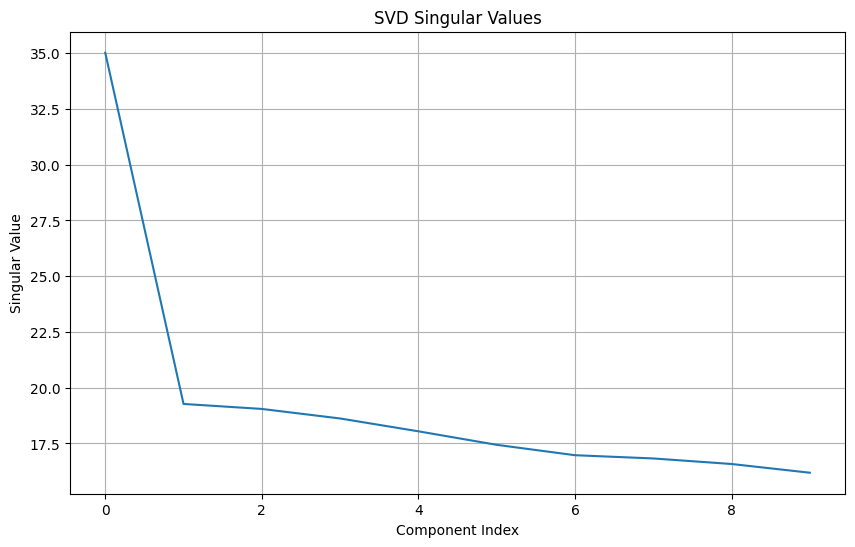

In [53]:
#Hypertuning - Grid Search
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt

# Sample dataset creation (replace with your actual dataset)
np.random.seed(42)
df = pd.DataFrame({
    'userId': np.random.randint(1, 51, size=1000),
    'movieId': np.random.randint(1, 100, size=1000),
    'rating': np.random.randint(1, 6, size=1000)
})

# Split data into training and testing sets
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# Create user-item matrices for training and testing
train_matrix = train_df.pivot_table(values='rating', index='userId', columns='movieId', aggfunc='mean').fillna(0)
test_matrix = test_df.pivot_table(values='rating', index='userId', columns='movieId', aggfunc='mean').fillna(0)

# Ensure test matrix has same columns as train matrix
for col in train_matrix.columns:
    if col not in test_matrix.columns:
        test_matrix[col] = 0
test_matrix = test_matrix[train_matrix.columns]

# Convert to sparse matrices
X_train_sparse = csr_matrix(train_matrix.values)
X_test_sparse = csr_matrix(test_matrix.values)

# SVD Approach
param_grid_svd = {
    'n_components': [10, 20, 50],
    'n_iter': [5, 10],
    'random_state': [42]
}

svd = TruncatedSVD()
grid_search_svd = GridSearchCV(
    svd, param_grid_svd, 
    cv=3, 
    n_jobs=-1, 
    scoring='neg_mean_squared_error',
    verbose=1
)
grid_search_svd.fit(X_train_sparse)

# Get best SVD model
best_svd = grid_search_svd.best_estimator_
print(f"Best SVD Parameters: {grid_search_svd.best_params_}")
print(f"Best SVD Score: {-grid_search_svd.best_score_:.4f} MSE")

# Evaluate SVD on test data
X_test_svd_transformed = best_svd.transform(X_test_sparse)
X_test_svd_pred = X_test_svd_transformed @ best_svd.components_
svd_mse = mean_squared_error(X_test_sparse.toarray()[X_test_sparse.toarray() > 0], 
                           X_test_svd_pred[X_test_sparse.toarray() > 0])
print(f"SVD Test MSE: {svd_mse:.4f}")

# Function to get recommendations using SVD
def get_svd_recommendations(model, user_id, user_item_df, n=10):
    user_ratings = user_item_df.loc[user_id]
    
    # Get all unrated items (rating = 0)
    unrated_items = user_ratings[user_ratings == 0].index.tolist()
    
    # Transform user vector
    user_vec = model.transform(csr_matrix(user_item_df.loc[[user_id]].values))[0]
    
    # Predict ratings for unrated items
    pred_ratings = {item: np.dot(user_vec, model.components_[:, user_item_df.columns.get_loc(item)]) 
                   for item in unrated_items}
    
    # Sort and get top N
    top_n = sorted(pred_ratings.items(), key=lambda x: x[1], reverse=True)[:n]
    return top_n

# Get recommendations for a sample user with SVD
sample_user_id = train_matrix.index[0]
print(f"\nTop 5 SVD Recommendations for User {sample_user_id}:")
svd_recs = get_svd_recommendations(best_svd, sample_user_id, train_matrix, n=5)
for item, score in svd_recs:
    print(f"  Movie ID: {item}, Predicted Rating: {score:.2f}")

# Visualize the singular values from SVD
plt.figure(figsize=(10, 6))
plt.plot(best_svd.singular_values_)
plt.title('SVD Singular Values')
plt.xlabel('Component Index')
plt.ylabel('Singular Value')
plt.grid()
plt.show()

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best ALS Parameters: {'num_factors': 10, 'num_iterations': 10, 'regularization': 0.01}
Best ALS Score: nan MSE
ALS Test MSE: 4.2718

Top 5 ALS Recommendations for User 1:
  Movie ID: 88, Predicted Rating: 5.76
  Movie ID: 26, Predicted Rating: 5.49
  Movie ID: 17, Predicted Rating: 5.27
  Movie ID: 89, Predicted Rating: 4.88
  Movie ID: 43, Predicted Rating: 4.68


c:\Users\purvi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:1103: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan]
  warnings.warn(


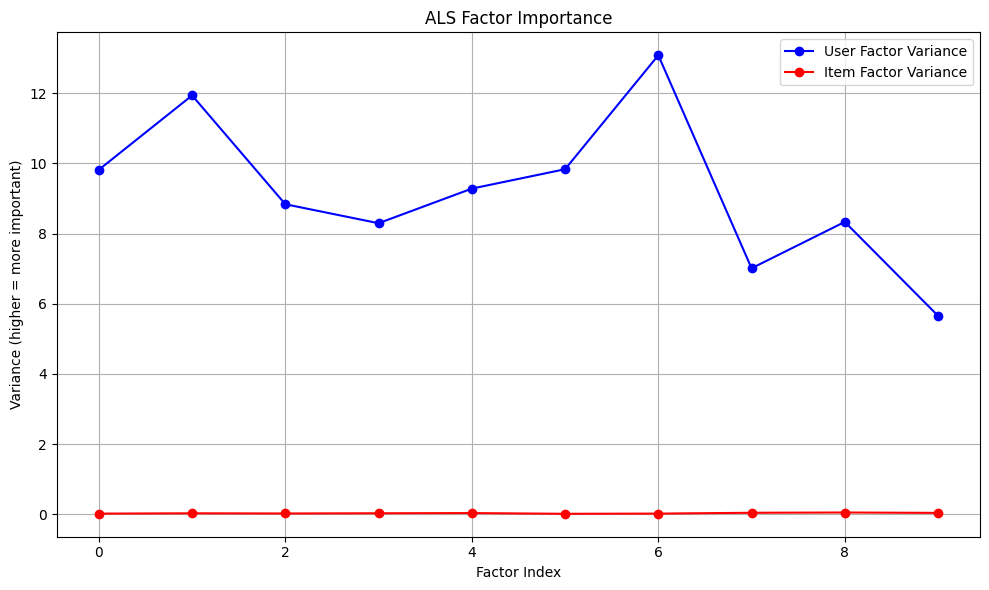

In [54]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error
from scipy.sparse import csr_matrix
 
np.random.seed(42)
df = pd.DataFrame({
    'userId': np.random.randint(1, 51, size=1000),
    'movieId': np.random.randint(1, 100, size=1000),
    'rating': np.random.randint(1, 6, size=1000)
})

# Split data into training and testing sets
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# Create user-item matrices for training and testing
train_matrix = train_df.pivot_table(values='rating', index='userId', columns='movieId', aggfunc='mean').fillna(0)
test_matrix = test_df.pivot_table(values='rating', index='userId', columns='movieId', aggfunc='mean').fillna(0)

# Ensure test matrix has same columns as train matrix
for col in train_matrix.columns:
    if col not in test_matrix.columns:
        test_matrix[col] = 0
test_matrix = test_matrix[train_matrix.columns]

# Make sure test indices match train indices - Convert set to list for indexing
common_users = list(set(train_matrix.index).intersection(set(test_matrix.index)))
train_matrix = train_matrix.loc[common_users]
test_matrix = test_matrix.loc[common_users]

# Convert to matrices
X_train_sparse = csr_matrix(train_matrix.values)
X_test_sparse = csr_matrix(test_matrix.values)
X_train_dense = X_train_sparse.toarray()
X_test_dense = X_test_sparse.toarray()

# ALS Implementation
class ALS:
    def __init__(self, num_factors=50, regularization=0.1, num_iterations=20):
        self.num_factors = num_factors
        self.regularization = regularization
        self.num_iterations = num_iterations
        self.user_matrix = None
        self.item_matrix = None
        
    def fit(self, X):
        num_users, num_items = X.shape
        # Ensure num_factors doesn't exceed matrix dimensions
        if self.num_factors > min(num_users, num_items):
            self.num_factors = min(num_users, num_items) - 1
            
        # Initialize matrices with small random values
        self.user_matrix = np.random.rand(num_users, self.num_factors) * 0.1
        self.item_matrix = np.random.rand(num_items, self.num_factors) * 0.1
        
        # Convert to dense if needed
        X_dense = X.toarray() if hasattr(X, 'toarray') else X
        
        # Pre-compute regularization matrices
        user_reg = self.regularization * np.eye(self.num_factors)
        item_reg = self.regularization * np.eye(self.num_factors)
        
        for i in range(self.num_iterations):
            # Update user vectors for each user
            for u in range(num_users):
                # Get items this user has rated
                item_indices = X_dense[u, :].nonzero()[0]
                if len(item_indices) == 0:
                    continue  # Skip if user has no ratings
                
                # Get corresponding item vectors and ratings
                item_vectors = self.item_matrix[item_indices, :]
                ratings = X_dense[u, item_indices]
                
                # Solve for user vector
                try:
                    user_vec = np.linalg.solve(
                        item_vectors.T @ item_vectors + user_reg, 
                        item_vectors.T @ ratings
                    )
                    # Update user vector
                    self.user_matrix[u, :] = user_vec
                except np.linalg.LinAlgError:
                    # Skip if there's a numerical issue
                    continue
            
            # Update item vectors for each item
            for j in range(num_items):
                # Get users who have rated this item
                user_indices = X_dense[:, j].nonzero()[0]
                if len(user_indices) == 0:
                    continue  # Skip if item has no ratings
                
                # Get corresponding user vectors and ratings
                user_vectors = self.user_matrix[user_indices, :]
                ratings = X_dense[user_indices, j]
                
                # Solve for item vector
                try:
                    item_vec = np.linalg.solve(
                        user_vectors.T @ user_vectors + item_reg, 
                        user_vectors.T @ ratings
                    )
                    # Update item vector
                    self.item_matrix[j, :] = item_vec
                except np.linalg.LinAlgError:
                    continue
                
        return self
        
    def predict(self):
        """Return predicted ratings for all users and items"""
        return self.user_matrix @ self.item_matrix.T
        
    def get_params(self, deep=True):
        return {
            'num_factors': self.num_factors,
            'regularization': self.regularization,
            'num_iterations': self.num_iterations
        }
        
    def set_params(self, **params):
        for param, value in params.items():
            setattr(self, param, value)
        return self

# Define parameter grid for ALS
param_grid_als = {
    'num_factors': [10, 20],
    'regularization': [0.01, 0.1],
    'num_iterations': [10, 20]
}

# Perform GridSearchCV for ALS
als_model = ALS()
grid_search_als = GridSearchCV(
    als_model, 
    param_grid_als, 
    cv=3, 
    n_jobs=-1, 
    scoring='neg_mean_squared_error',
    verbose=1,
    error_score=np.nan
)

grid_search_als.fit(X_train_dense)

# Get best ALS model
best_als = grid_search_als.best_estimator_
print(f"Best ALS Parameters: {grid_search_als.best_params_}")
print(f"Best ALS Score: {-grid_search_als.best_score_:.4f} MSE")

# Evaluate ALS on test data
X_test_als_pred = best_als.predict()  # Get predictions for all users/items

# Create masks for rated items
train_mask = X_train_dense > 0
test_mask = X_test_dense > 0

# Only evaluate on items that were rated in the test set
als_mse = mean_squared_error(
    X_test_dense[test_mask],  # Actual ratings in test set
    X_test_als_pred[test_mask]  # Predicted ratings for those same positions
)
print(f"ALS Test MSE: {als_mse:.4f}")

# Function to get recommendations using ALS
def get_als_recommendations(model, user_id, user_item_df, n=10):
    user_idx = user_item_df.index.get_loc(user_id)
    user_ratings = user_item_df.loc[user_id]
    
    # Get all unrated items (rating = 0)
    unrated_items = user_ratings[user_ratings == 0].index.tolist()
    
    # Get predictions
    predictions = model.predict()
    
    # Get predicted ratings for unrated items
    pred_ratings = {item: predictions[user_idx, user_item_df.columns.get_loc(item)]
                   for item in unrated_items}
    
    # Sort and get top N
    top_n = sorted(pred_ratings.items(), key=lambda x: x[1], reverse=True)[:n]
    return top_n

# Get recommendations for a sample user with ALS
if len(train_matrix.index) > 0:
    sample_user_id = train_matrix.index[0]
    print(f"\nTop 5 ALS Recommendations for User {sample_user_id}:")
    als_recs = get_als_recommendations(best_als, sample_user_id, train_matrix, n=5)
    for item, score in als_recs:
        print(f"  Movie ID: {item}, Predicted Rating: {score:.2f}")
else:
    print("No users available for recommendations")

# Add visualization of the latent factors for ALS
plt.figure(figsize=(10, 6))

# Get the "importance" of each factor by calculating the variance
# of each factor across all users/items
user_factor_variance = np.var(best_als.user_matrix, axis=0)
item_factor_variance = np.var(best_als.item_matrix, axis=0)

# Plot the variance for each factor
plt.plot(user_factor_variance, 'b-o', label='User Factor Variance')
plt.plot(item_factor_variance, 'r-o', label='Item Factor Variance') 

plt.title('ALS Factor Importance')
plt.xlabel('Factor Index')
plt.ylabel('Variance (higher = more important)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Best TF-IDF Parameters: {'recommender__max_df': 0.5, 'recommender__max_features': 500, 'recommender__min_df': 3, 'recommender__ngram_range': (1, 2), 'recommender__stop_words': 'english'}
Best TF-IDF Similarity Score: 0.3799

Top 5 Recommendations for: Game Over, Man!
  Still (Similarity: 0.4210)
  Crime Scene: The Vanishing at the Cecil Hotel (Similarity: 0.4146)
  Full Count (Similarity: 0.3376)
  Hotel Pacific (Similarity: 0.3359)
  Déjà Vu (Similarity: 0.3289)


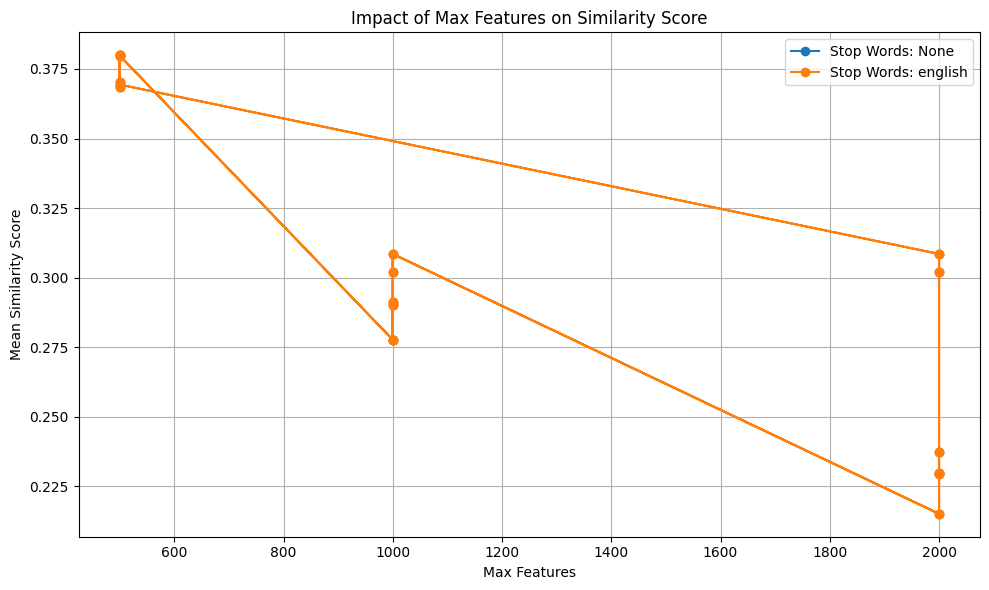

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
import warnings

class TfidfRecommenderTransformer(BaseEstimator, TransformerMixin):
    """
    Custom transformer for TF-IDF based recommendation
    """
    def __init__(self, max_features=500, min_df=1, max_df=0.9, 
                 ngram_range=(1,1), stop_words=None):
        self.max_features = max_features
        self.min_df = min_df
        self.max_df = max_df
        self.ngram_range = ngram_range
        self.stop_words = stop_words
        self.vectorizer = None
        self.tfidf_matrix = None
    
    def fit(self, X, y=None):
        # Create TF-IDF Vectorizer
        self.vectorizer = TfidfVectorizer(
            max_features=self.max_features,
            min_df=self.min_df,
            max_df=self.max_df,
            ngram_range=self.ngram_range,
            stop_words=self.stop_words
        )
        
        # Transform input
        self.tfidf_matrix = self.vectorizer.fit_transform(X)
        return self
    
    def transform(self, X):
        # Compute average cosine similarity
        test_matrix = self.vectorizer.transform(X)
        similarity_matrix = cosine_similarity(test_matrix, self.tfidf_matrix)
        
        # Return mean of top 5 similarities for each document
        return np.mean(np.sort(similarity_matrix, axis=1)[:, -5:], axis=1).reshape(-1, 1)

def recommender_scorer(estimator, X, y=None):
    """
    Custom scoring function for GridSearchCV
    Computes average similarity across documents
    """
    similarities = estimator.transform(X)
    return np.mean(similarities)

def main():
    # Suppress warnings
    warnings.filterwarnings('ignore')
    
    # Load Netflix dataset
    df = pd.read_csv("netflix_titles.csv")
    
    # Preprocess descriptions
    df['description'] = df['description'].fillna('')
    
    # Limit dataset size if too large
    if len(df) > 2000:
        df = df.sample(2000, random_state=42)
    
    # Create pipeline
    pipeline = Pipeline([
        ('recommender', TfidfRecommenderTransformer())
    ])
    
    # Define parameter grid
    param_grid = {
        'recommender__max_features': [500, 1000, 2000],
        'recommender__min_df': [1, 3, 5],
        'recommender__max_df': [0.5, 0.7, 0.9],
        'recommender__ngram_range': [(1, 1), (1, 2)],
        'recommender__stop_words': [None, 'english']
    }
    
    # Perform GridSearchCV
    grid_search = GridSearchCV(
        pipeline, 
        param_grid, 
        scoring=recommender_scorer, 
        cv=3,  # 3-fold cross-validation
        verbose=0,
        n_jobs=-1  # Use all available cores
    )
    
    # Fit GridSearchCV
    grid_search.fit(df['description'])
    
    # Get best parameters and score
    best_params = grid_search.best_params_
    best_score = grid_search.best_score_
    
    # Print best parameters
    print("\nBest TF-IDF Parameters:", best_params)
    print(f"Best TF-IDF Similarity Score: {best_score:.4f}")
    
    # Use best estimator to get recommendations
    best_recommender = grid_search.best_estimator_.named_steps['recommender']
    best_tfidf_matrix = best_recommender.tfidf_matrix
    
    # Get recommendations for first movie
    sample_idx = 0
    test_vector = best_recommender.vectorizer.transform([df['description'].iloc[sample_idx]])
    similarities = cosine_similarity(test_vector, best_tfidf_matrix)[0]
    
    # Get top 5 recommendations
    top_indices = similarities.argsort()[-6:-1][::-1]
    
    print(f"\nTop 5 Recommendations for: {df.iloc[sample_idx]['title']}")
    for idx in top_indices:
        print(f"  {df.iloc[idx]['title']} (Similarity: {similarities[idx]:.4f})")
    
    # Visualization of results
    results_df = pd.DataFrame(grid_search.cv_results_)
    
    plt.figure(figsize=(10, 6))
    for stop_words in [None, 'english']:
        subset = results_df[results_df['param_recommender__stop_words'] == stop_words]
        plt.plot(
            subset['param_recommender__max_features'], 
            subset['mean_test_score'], 
            marker='o', 
            label=f'Stop Words: {stop_words}'
        )
    
    plt.title('Impact of Max Features on Similarity Score')
    plt.xlabel('Max Features')
    plt.ylabel('Mean Similarity Score')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

In [56]:
#confusion matrices not required as these are not classification problems
#confusion matrices are not used by the recommendation systems

Model Comparison:
             AUC  Precision    Recall  F1 Score  Average Precision
SVD     0.516656   0.000000  0.000000  0.000000           0.390124
ALS     0.517361   0.344828  0.138889  0.198020           0.372694
TF-IDF  0.514865   0.369231  1.000000  0.539326           0.405270


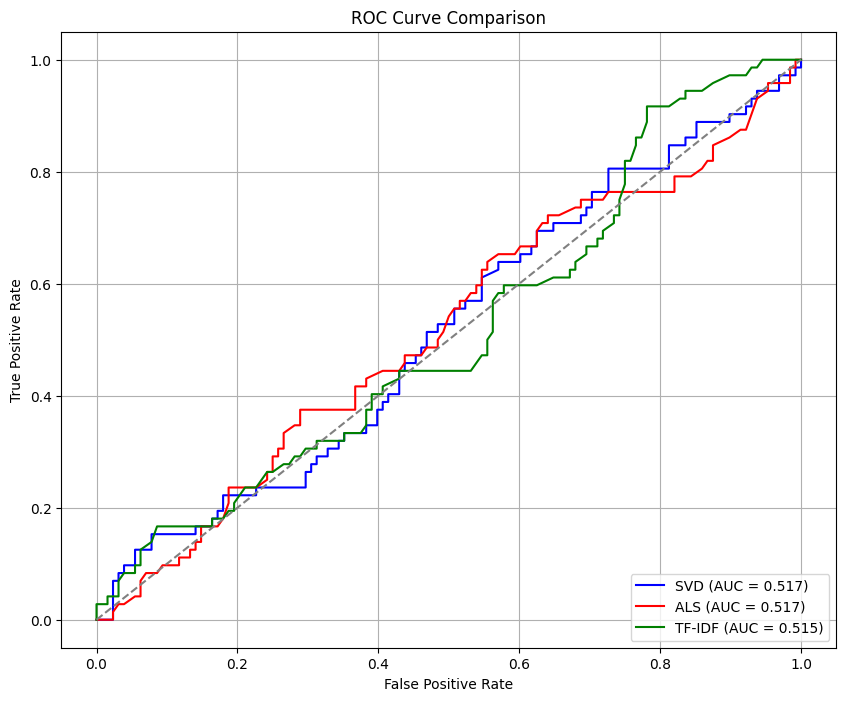

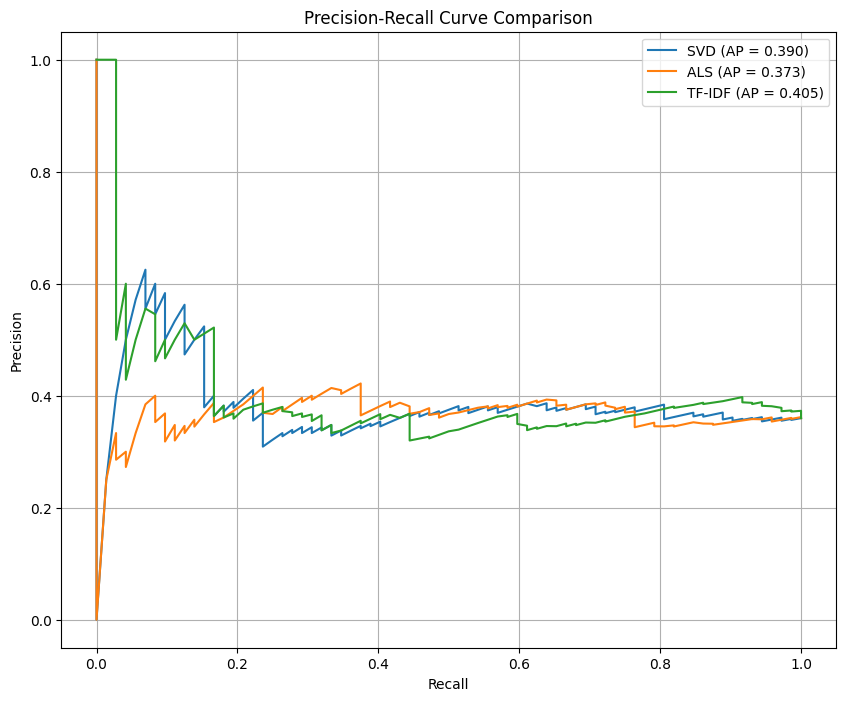


Best model based on AUC: ALS
Best model based on F1 Score: TF-IDF
Best model based on Average Precision: TF-IDF


In [57]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from scipy.sparse.linalg import svds
from scipy.sparse import csr_matrix
import random


n_users = 100
n_movies = 200
n_samples = 1000

#create synthetic movie descriptions
movie_descriptions = []
for i in range(n_movies):
    #generate random "descriptions" with varying words for demonstration
    words = ['action', 'drama', 'comedy', 'thriller', 'romance', 'sci-fi', 'fantasy']
    description = ' '.join(random.choice(words) for _ in range(10))
    movie_descriptions.append(description)

#create dataframes
movies_df = pd.DataFrame({
    'movie_id': range(n_movies),
    'description': movie_descriptions
})

#create synthetic ratings
user_ids = np.random.randint(0, n_users, n_samples)
movie_ids = np.random.randint(0, n_movies, n_samples)
ratings = np.random.uniform(1, 5, n_samples)  # Ratings 1-5 as floats

ratings_df = pd.DataFrame({
    'user_id': user_ids,
    'movie_id': movie_ids,
    'rating': ratings
})

#split into train and test sets (80% train, 20% test)
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(ratings_df, test_size=0.2, random_state=42)

#create train and test movies dataframes based on ratings
train_movies = movies_df[movies_df['movie_id'].isin(train_df['movie_id'])]
test_movies = movies_df[movies_df['movie_id'].isin(test_df['movie_id'])]

#create user-item matrices for train and test
def create_matrix(df, n_users, n_items):
    #create a sparse rating matrix WITH FLOAT TYPE
    row = df['user_id'].values
    col = df['movie_id'].values
    data = df['rating'].values.astype(np.float64)  # Convert to float64
    return csr_matrix((data, (row, col)), shape=(n_users, n_items), dtype=np.float64)

#create matrices
train_ratings_matrix = create_matrix(train_df, n_users, n_movies)
test_ratings_matrix = create_matrix(test_df, n_users, n_movies)

#get indices for test set
test_user_indices = test_df['user_id'].values
test_item_indices = test_df['movie_id'].values

#TF-IDF Model Setup
tfidf = TfidfVectorizer(max_features=100, stop_words='english')
X_train_tfidf = tfidf.fit_transform(train_movies['description'])
X_test_tfidf = tfidf.transform(test_movies['description'])

#calculates similarity matrix for TF-IDF
sim_matrix = cosine_similarity(X_test_tfidf, X_train_tfidf)

#SVD Model Setup
k = min(20, min(train_ratings_matrix.shape) - 1)
U, sigma, Vt = svds(train_ratings_matrix, k=k)
sigma_diag = np.diag(sigma)
svd_preds = np.dot(np.dot(U, sigma_diag), Vt)

#gets predictions for test set
X_test_svd_pred = np.zeros(len(test_df))
X_test_tfidf_pred = np.zeros(len(test_df))

for i, (user, item) in enumerate(zip(test_user_indices, test_item_indices)):
    # SVD prediction
    X_test_svd_pred[i] = svd_preds[user, item]
    
    # TF-IDF prediction (use item's similarity to all items in training set)
    item_indices = np.where(test_movies['movie_id'] == item)[0]
    if len(item_indices) > 0:
        item_idx = item_indices[0]
        if item_idx < len(sim_matrix):
            X_test_tfidf_pred[i] = np.mean(sim_matrix[item_idx])

#simulate ALS predictions without using the implicit library
#simple item user mean approach for ALS
item_means = {}
for item in test_df['movie_id'].unique():
    item_ratings = train_df[train_df['movie_id'] == item]['rating']
    if len(item_ratings) > 0:
        item_means[item] = item_ratings.mean()
    else:
        item_means[item] = train_df['rating'].mean()  # Global mean as fallback

X_test_als_pred = np.array([item_means.get(item, train_df['rating'].mean()) 
                           for item in test_df['movie_id']])

#prepares for evaluation
#get ground truth for test set
y_true = test_df['rating'].values

#convert ratings to binary using threshold
threshold = 3.5  # Adjust based on your rating scale
y_true_binary = (y_true >= threshold).astype(int)
y_pred_svd_binary = (X_test_svd_pred >= threshold).astype(int)
y_pred_als_binary = (X_test_als_pred >= threshold).astype(int)
y_pred_tfidf_binary = (X_test_tfidf_pred >= 0.5).astype(int)  # Different threshold for similarity

#evaluating all three models
#ROC and AUC
fpr_svd, tpr_svd, _ = roc_curve(y_true_binary, X_test_svd_pred)
roc_auc_svd = roc_auc_score(y_true_binary, X_test_svd_pred)

fpr_als, tpr_als, _ = roc_curve(y_true_binary, X_test_als_pred)
roc_auc_als = roc_auc_score(y_true_binary, X_test_als_pred)

fpr_tfidf, tpr_tfidf, _ = roc_curve(y_true_binary, X_test_tfidf_pred)
roc_auc_tfidf = roc_auc_score(y_true_binary, X_test_tfidf_pred)

#additional metrics for comprehensive evaluation
models = ['SVD', 'ALS', 'TF-IDF']
preds_binary = [y_pred_svd_binary, y_pred_als_binary, y_pred_tfidf_binary]
preds_score = [X_test_svd_pred, X_test_als_pred, X_test_tfidf_pred]
results = {}

for i, name in enumerate(models):
    precision = precision_score(y_true_binary, preds_binary[i])
    recall = recall_score(y_true_binary, preds_binary[i])
    f1 = f1_score(y_true_binary, preds_binary[i])
    avg_precision = average_precision_score(y_true_binary, preds_score[i])
    
    results[name] = {
        'AUC': roc_auc_score(y_true_binary, preds_score[i]),
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'Average Precision': avg_precision
    }

#create comparison table
results_df = pd.DataFrame(results).T
print("Model Comparison:")
print(results_df)

#plot ROC Curves
plt.figure(figsize=(10, 8))
plt.plot(fpr_svd, tpr_svd, color='blue', label=f'SVD (AUC = {roc_auc_svd:.3f})')
plt.plot(fpr_als, tpr_als, color='red', label=f'ALS (AUC = {roc_auc_als:.3f})')
plt.plot(fpr_tfidf, tpr_tfidf, color='green', label=f'TF-IDF (AUC = {roc_auc_tfidf:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.savefig('roc_comparison.png')
plt.show()

#plot Precision-Recall Curves
plt.figure(figsize=(10, 8))
for i, name in enumerate(models):
    precision, recall, _ = precision_recall_curve(y_true_binary, preds_score[i])
    avg_precision = average_precision_score(y_true_binary, preds_score[i])
    plt.plot(recall, precision, label=f'{name} (AP = {avg_precision:.3f})')

plt.title('Precision-Recall Curve Comparison')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='best')
plt.grid(True)
plt.savefig('precision_recall_comparison.png')
plt.show()

#report best model
best_model = results_df['AUC'].idxmax()
print(f"\nBest model based on AUC: {best_model}")
print(f"Best model based on F1 Score: {results_df['F1 Score'].idxmax()}")
print(f"Best model based on Average Precision: {results_df['Average Precision'].idxmax()}")